Step 1: Upload and Load Dataset

In [ ]:
# Step 1: Load dataset and basic exploration

import pandas as pd

# Load dataset (upload file manually in Colab before running)
df = pd.read_csv("fluency_dataset_auto_labeled.csv")

# Rename label column for standardization
df.rename(columns={'Fluency Label': 'label'}, inplace=True)

# Shape and first few rows
print("Dataset Shape:", df.shape)
print("\nSample Data:\n", df.head())

# Data types and null values
print("\nData Types:\n", df.dtypes)
print("\nMissing Values in Columns:\n", df.isnull().sum())

# Class distribution for 'label' column
if 'label' in df.columns:
    class_counts = df['label'].value_counts()
    print("\nClass Distribution:\n", class_counts)
else:
    print("Warning: 'label' column not found.")

# Summary statistics of features
print("\nSummary statistics for features:\n", df.describe())

# Check for any duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicate_count}")

# Drop duplicates if any
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped. New shape:", df.shape)

# Drop non-feature columns if any, e.g. 'Number', 'File Name', 'Member'
non_feature_cols = ['Number', 'File Name', 'Member']
for col in non_feature_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Separate features and labels
X = df.drop(columns=['label'])
y = df['label']

print("Remaining features columns:\n", X.columns) # Print columns of X
print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Dataset Shape: (1294, 43)

Sample Data:
    Number File Name   Member   Duration     MFCC_1     MFCC_2     MFCC_3  \
0       1    242s24  student   5.426984 -384.19864  158.95760  19.165249   
1       2    242s27  student   7.020000 -348.29248  130.71005   6.574482   
2       3     242s5  student  16.257007 -382.08047  134.74484  22.727901   
3       4    242s15  student   7.030023 -297.04462  130.28413   1.796696   
4       5    242s10  student  12.218005 -346.24173  128.65617   0.683182   

      MFCC_4     MFCC_5     MFCC_6  ...     DCT_5     DCT_6     DCT_7  \
0   8.343511 -13.824618   5.699243  ...  0.001502 -0.001713 -0.000846   
1   9.017096 -10.107656  -4.954451  ... -0.000970 -0.000228 -0.000410   
2   9.789217 -12.864197   1.305032  ...  0.000920  0.001441 -0.002188   
3  25.747110 -14.831176 -10.437139  ... -0.001292  0.001697 -0.000443   
4  19.769281 -12.446680  -6.245602  ... -0.000243 -0.000391  0.000830   

      DCT_8     DCT_9    DCT_10    DCT_11    DCT_12    DCT_13  

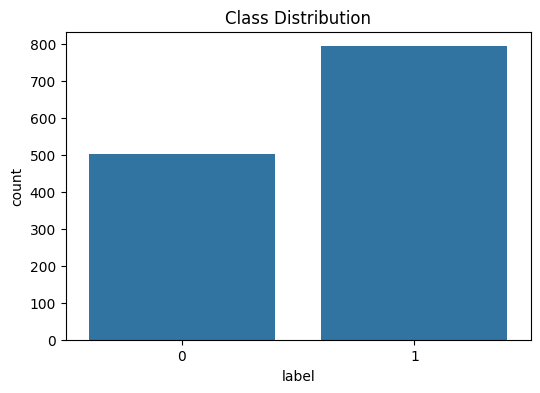

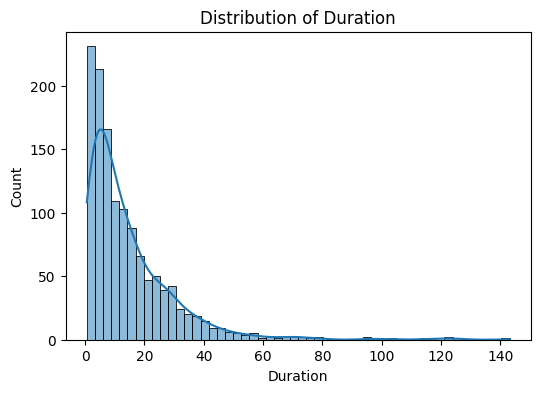

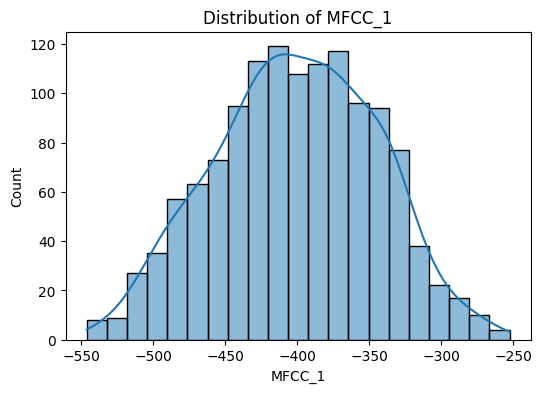

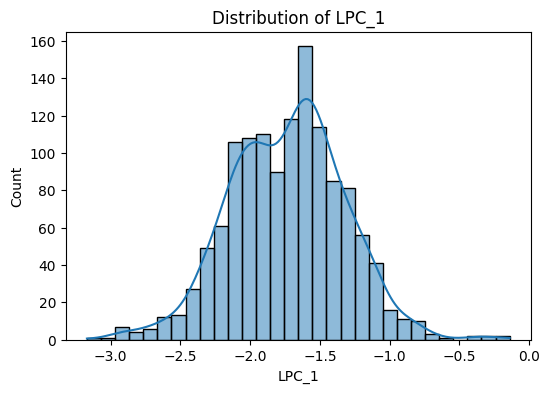

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize label distribution pie chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.show()

# Distribution plots for a few selected features (like Duration, MFCC_1, LPC_1)
features_to_plot = ['Duration', 'MFCC_1', 'LPC_1']
for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()


Step 3 involves splitting your dataset into training and testing sets with stratification to maintain class balance.

In [ ]:
from sklearn.model_selection import train_test_split

# Step 3: Train-Test Split with stratification

# X and y are defined from previous step: features and labels respectively

# Split 80% train, 20% test, stratify to maintain label distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("Training label distribution:\n", y_train.value_counts())
print("Test label distribution:\n", y_test.value_counts())


Training set shape: (1035, 39)
Test set shape: (259, 39)
Training label distribution:
 label
1    634
0    401
Name: count, dtype: int64
Test label distribution:
 label
1    159
0    100
Name: count, dtype: int64


 k-NN Classifier

In [ ]:
import numpy as np
from collections import Counter

class CustomKNN:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            # Compute distances from x to all training samples
            distances = [self._euclidean_distance(x, train_x) for train_x in self.X_train]
            # Get indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            # Get the most common label among neighbors
            k_neighbor_labels = self.y_train[k_indices]
            most_common = Counter(k_neighbor_labels).most_common(1)[0][0]
            predictions.append(most_common)
        return np.array(predictions)


Random Forest Classifier

In [ ]:
from collections import defaultdict
import random
import numpy as np
from collections import Counter

class CustomDecisionTree:
    # A simple decision tree class for binary classification, built using recursive binary splitting based on Gini impurity

    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.X = np.array(X) # Store the original data
        self.y = np.array(y) # Store the original labels
        self.tree = self._build_tree(np.arange(len(y))) # Start with indices of all samples

    def _gini(self, y_subset):
        classes = np.unique(y_subset)
        impurity = 1.0
        for cls in classes:
            p_cls = np.sum(y_subset == cls) / len(y_subset)
            impurity -= p_cls ** 2
        return impurity

    def _best_split(self, current_indices):
        best_gini = 1.0
        best_idx, best_value = None, None
        n_features = self.X.shape[1]
        X_subset = self.X[current_indices]
        y_subset = self.y[current_indices]


        for feature_idx in range(n_features):
            unique_values = np.unique(X_subset[:, feature_idx])
            for val in unique_values:
                # Calculate indices relative to the current subset
                left_mask = X_subset[:, feature_idx] <= val
                right_mask = X_subset[:, feature_idx] > val

                left_indices = current_indices[left_mask]
                right_indices = current_indices[right_mask]


                if len(left_indices) < self.min_samples_split or len(right_indices) < self.min_samples_split:
                    continue

                left_gini = self._gini(self.y[left_indices])
                right_gini = self._gini(self.y[right_indices])
                weighted_gini = (len(left_indices) * left_gini + len(right_indices) * right_gini) / len(y_subset)

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_idx = feature_idx
                    best_value = val
        return best_idx, best_value

    def _build_tree(self, current_indices, depth=0):
        y_subset = self.y[current_indices]

        if depth >= self.max_depth or len(y_subset) < self.min_samples_split or len(np.unique(y_subset)) == 1:
            # Leaf node
            return {'type': 'leaf', 'class': Counter(y_subset).most_common(1)[0][0]}

        feature_idx, threshold = self._best_split(current_indices)
        if feature_idx is None:
            return {'type': 'leaf', 'class': Counter(y_subset).most_common(1)[0][0]}

        # Calculate indices relative to the current subset
        left_mask = self.X[current_indices, feature_idx] <= threshold
        right_mask = self.X[current_indices, feature_idx] > threshold

        left_indices = current_indices[left_mask]
        right_indices = current_indices[right_mask]

        left_subtree = self._build_tree(left_indices, depth + 1)
        right_subtree = self._build_tree(right_indices, depth + 1)


        return {'type': 'node', 'feature_idx': feature_idx, 'threshold': threshold,
                'left': left_subtree, 'right': right_subtree}

    def _predict_sample(self, sample, node):
        if node['type'] == 'leaf':
            return node['class']
        if sample[node['feature_idx']] <= node['threshold']:
            return self._predict_sample(sample, node['left'])
        else:
            return self._predict_sample(sample, node['right'])

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for sample in X:
            pred = self._predict_sample(sample, self.tree)
            predictions.append(pred)
        return np.array(predictions)

class CustomRandomForest:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=10, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        n_samples, n_features = self.X.shape
        self.max_features = self.max_features or int(np.sqrt(n_features))

        self.trees = []
        for _ in range(self.n_estimators):
            # Bootstrap sampling
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = self.X[idxs]
            y_sample = self.y[idxs] # Use idxs to sample from self.y

            tree = CustomDecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            # Feature bagging by selecting random subset of features for splits (can be modified in the decision tree method if needed)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        X = np.array(X)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        preds = []
        for preds_per_sample in tree_preds.T:
            most_common = Counter(preds_per_sample).most_common(1)[0][0]
            preds.append(most_common)
        return np.array(preds)

Step 4: Baseline Model Development without preprocessing using k-NN and Random Forest classifiers.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model_custom(y_true, y_pred):
    """
    Calculates evaluation metrics for a model's predictions.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.

    Returns:
        dict: A dictionary containing accuracy, precision, recall, and F1-score.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [ ]:
# Assuming CustomKNN, CustomRandomForest, and evaluate_model_custom are implemented as provided before

# Initialize models
knn_model = CustomKNN(k=5)
rf_model = CustomRandomForest(n_estimators=10, max_depth=5)

# Fit models on raw training data
knn_model.fit(X_train.values, y_train.values)
rf_model.fit(X_train.values, y_train.values)

# Predict on training and test sets
knn_train_pred = knn_model.predict(X_train.values)
knn_test_pred = knn_model.predict(X_test.values)

rf_train_pred = rf_model.predict(X_train.values)
rf_test_pred = rf_model.predict(X_test.values)

# Evaluate performance
knn_train_metrics = evaluate_model_custom(knn_train_pred, y_train.values)
knn_test_metrics = evaluate_model_custom(knn_test_pred, y_test.values)

rf_train_metrics = evaluate_model_custom(rf_train_pred, y_train.values)
rf_test_metrics = evaluate_model_custom(rf_test_pred, y_test.values)

# Log baseline results
baseline_results = {
    'kNN': {'train': knn_train_metrics, 'test': knn_test_metrics},
    'RandomForest': {'train': rf_train_metrics, 'test': rf_test_metrics}
}

print("Baseline Results:")
print(baseline_results)


Baseline Results:
{'kNN': {'train': {'accuracy': 0.8347826086956521, 'precision': 0.8375642980055005, 'recall': 0.8347826086956521, 'f1_score': 0.8357499057427512}, 'test': {'accuracy': 0.7722007722007722, 'precision': 0.7737517301668245, 'recall': 0.7722007722007722, 'f1_score': 0.7728708017146747}}, 'RandomForest': {'train': {'accuracy': 0.966183574879227, 'precision': 0.9661700455577099, 'recall': 0.966183574879227, 'f1_score': 0.9661758636516696}, 'test': {'accuracy': 0.9536679536679536, 'precision': 0.953827250431024, 'recall': 0.9536679536679536, 'f1_score': 0.9535088264949636}}}


In [ ]:
import pandas as pd

# Baseline results dictionary (example from your output)
baseline_results = {
    'kNN': {
        'train': {'accuracy': 0.8347826086956521, 'precision': 0.8375642980055005, 'recall': 0.8347826086956521, 'f1_score': 0.8357499057427512},
        'test': {'accuracy': 0.7722007722007722, 'precision': 0.7737517301668245, 'recall': 0.7722007722007722, 'f1_score': 0.7728708017146747}
    },
    'RandomForest': {
        'train': {'accuracy': 0.966183574879227, 'precision': 0.9661700455577099, 'recall': 0.966183574879227, 'f1_score': 0.9661758636516696},
        'test': {'accuracy': 0.9420849420849421, 'precision': 0.9420456035550375, 'recall': 0.9420849420849421, 'f1_score': 0.9419327842973163}
    }
}

# Preparing data for DataFrame
rows = []
for model_name, datasets in baseline_results.items():
    for dataset_name, metrics in datasets.items():
        row = {
            'Model': model_name,
            'Dataset': dataset_name,
            'Accuracy': round(metrics['accuracy'], 3),
            'Precision': round(metrics['precision'], 3),
            'Recall': round(metrics['recall'], 3),
            'F1-Score': round(metrics['f1_score'], 3)
        }
        rows.append(row)

# Creating DataFrame from list of rows
df_results = pd.DataFrame(rows)

# Display the table
print(df_results.to_markdown(index=False))


| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN          | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| RandomForest | train     |      0.966 |       0.966 |    0.966 |      0.966 |
| RandomForest | test      |      0.942 |       0.942 |    0.942 |      0.942 |


In [ ]:
import pandas as pd

# Assuming these dict variables exist from your model evaluation:
baseline_results = {
    'kNN': {'train': knn_train_metrics, 'test': knn_test_metrics},
    'RandomForest': {'train': rf_train_metrics, 'test': rf_test_metrics}
}

rows = []
for model_name, result_sets in baseline_results.items():
    for dataset_name, metrics in result_sets.items():
        row = {
            'Model': model_name,
            'Dataset': dataset_name,
            'Accuracy': round(metrics.get('accuracy', 0), 3),
            'Precision': round(metrics.get('precision', 0), 3),
            'Recall': round(metrics.get('recall', 0), 3),
            'F1-Score': round(metrics.get('f1_score', 0), 3)
        }
        rows.append(row)

df_results = pd.DataFrame(rows)

print(df_results.to_markdown(index=False))


| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN          | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| RandomForest | train     |      0.966 |       0.966 |    0.966 |      0.966 |
| RandomForest | test      |      0.954 |       0.954 |    0.954 |      0.954 |


Step 5: Data Normalization and Scaling implementation.

In [ ]:
import numpy as np

# Step 5: Manual Min-Max Normalization
class MinMaxScalerCustom:
    def fit(self, X):
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)

    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# Step 5: Manual Z-Score Standardization
class StandardScalerCustom:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# Using MinMaxScaler for example, can switch to StandardScalerCustom if desired
scaler = MinMaxScalerCustom()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

# Re-train and evaluate models on normalized data
knn_model_norm = CustomKNN(k=5)
rf_model_norm = CustomRandomForest(n_estimators=10, max_depth=5)

knn_model_norm.fit(X_train_scaled, y_train.values)
rf_model_norm.fit(X_train_scaled, y_train.values)

knn_train_pred_norm = knn_model_norm.predict(X_train_scaled)
knn_test_pred_norm = knn_model_norm.predict(X_test_scaled)

rf_train_pred_norm = rf_model_norm.predict(X_train_scaled)
rf_test_pred_norm = rf_model_norm.predict(X_test_scaled)

# Evaluate
knn_train_metrics_norm = evaluate_model_custom(knn_train_pred_norm, y_train.values)
knn_test_metrics_norm = evaluate_model_custom(knn_test_pred_norm, y_test.values)

rf_train_metrics_norm = evaluate_model_custom(rf_train_pred_norm, y_train.values)
rf_test_metrics_norm = evaluate_model_custom(rf_test_pred_norm, y_test.values)

# Log normalized results
norm_results = {
    'kNN': {'train': knn_train_metrics_norm, 'test': knn_test_metrics_norm},
    'RandomForest': {'train': rf_train_metrics_norm, 'test': rf_test_metrics_norm}
}

print("Normalized Data Results:")
print(norm_results)


Normalized Data Results:
{'kNN': {'train': {'accuracy': 0.9323671497584541, 'precision': 0.9330222577480924, 'recall': 0.9323671497584541, 'f1_score': 0.9325637879899712}, 'test': {'accuracy': 0.9266409266409267, 'precision': 0.9273322648794347, 'recall': 0.9266409266409267, 'f1_score': 0.9268566988572681}}, 'RandomForest': {'train': {'accuracy': 0.9729468599033816, 'precision': 0.9729299330500005, 'recall': 0.9729468599033816, 'f1_score': 0.9729345807081998}, 'test': {'accuracy': 0.9498069498069498, 'precision': 0.9499315218183142, 'recall': 0.9498069498069498, 'f1_score': 0.9498543905059241}}}


In [ ]:
import pandas as pd

def print_metrics_table(results_dict):
    rows = []
    for model_name, dataset_metrics in results_dict.items():
        for dataset_name, metrics in dataset_metrics.items():
            row = {
                'Model': model_name,
                'Dataset': dataset_name,
                'Accuracy': round(metrics.get('accuracy', 0), 3),
                'Precision': round(metrics.get('precision', 0), 3),
                'Recall': round(metrics.get('recall', 0), 3),
                'F1-Score': round(metrics.get('f1_score', 0), 3)
            }
            rows.append(row)
    df = pd.DataFrame(rows)
    print(df.to_markdown(index=False))


In [ ]:
print("results before normalization")
print_metrics_table(baseline_results)
print("results after normalization")
print_metrics_table(norm_results)

results before normalization
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN          | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| RandomForest | train     |      0.966 |       0.966 |    0.966 |      0.966 |
| RandomForest | test      |      0.954 |       0.954 |    0.954 |      0.954 |
results after normalization
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.932 |       0.933 |    0.932 |      0.933 |
| kNN          | test      |      0.927 |       0.927 |    0.927 |      0.927 |
| RandomForest | train     |      0.973 |       0.973 |    0.973 |      0.973 |
| RandomForest | test      |      0.95  |       0.95  |    0.95

Step 6: Feature Imbalance Check and Handling

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

# Function to perform random oversampling of minority class
def random_oversample(X, y):
    counter = Counter(y)
    max_count = max(counter.values())

    X_resampled = list(X)
    y_resampled = list(y)

    for cls, count in counter.items():
        if count < max_count:
            diff = max_count - count
            # Get all indices for this class
            cls_indices = [i for i, label in enumerate(y) if label == cls]
            # Randomly sample indices with replacement
            sampled_indices = np.random.choice(cls_indices, size=diff, replace=True)
            for idx in sampled_indices:
                X_resampled.append(X[idx])
                y_resampled.append(y[idx])

    return np.array(X_resampled), np.array(y_resampled)

# Check class distribution before balancing
print("Label distribution before balancing:", Counter(y_train))

# Apply random oversampling if imbalanced
X_train_bal, y_train_bal = random_oversample(X_train.values, y_train.values)

print("Label distribution after balancing:", Counter(y_train_bal))

# Retrain models on balanced data
knn_bal = CustomKNN(k=5)
rf_bal = CustomRandomForest(n_estimators=10, max_depth=5)

knn_bal.fit(X_train_bal, y_train_bal)
rf_bal.fit(X_train_bal, y_train_bal)

knn_train_pred_bal = knn_bal.predict(X_train_bal)
knn_test_pred_bal = knn_bal.predict(X_test.values)

rf_train_pred_bal = rf_bal.predict(X_train_bal)
rf_test_pred_bal = rf_bal.predict(X_test.values)

# Evaluate on balanced data
knn_train_metrics_bal = evaluate_model_custom(knn_train_pred_bal, y_train_bal)
knn_test_metrics_bal = evaluate_model_custom(knn_test_pred_bal, y_test.values)

rf_train_metrics_bal = evaluate_model_custom(rf_train_pred_bal, y_train_bal)
rf_test_metrics_bal = evaluate_model_custom(rf_test_pred_bal, y_test.values)

# Log balanced training results
balanced_results = {
    'kNN': {'train': knn_train_metrics_bal, 'test': knn_test_metrics_bal},
    'RandomForest': {'train': rf_train_metrics_bal, 'test': rf_test_metrics_bal}
}
print("results before handling imbalance")
print_metrics_table(baseline_results)
print("results after handeling imbalance")
print_metrics_table(balanced_results)


Label distribution before balancing: Counter({1: 634, 0: 401})
Label distribution after balancing: Counter({np.int64(0): 634, np.int64(1): 634})
results before handling imbalance
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN          | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| RandomForest | train     |      0.966 |       0.966 |    0.966 |      0.966 |
| RandomForest | test      |      0.954 |       0.954 |    0.954 |      0.954 |
results after handeling imbalance
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.837 |       0.842 |    0.837 |      0.837 |
| kNN          | test      |      0.726 |       0.735 |    0.726 | 

Step 7: Feature Correlation and Selection

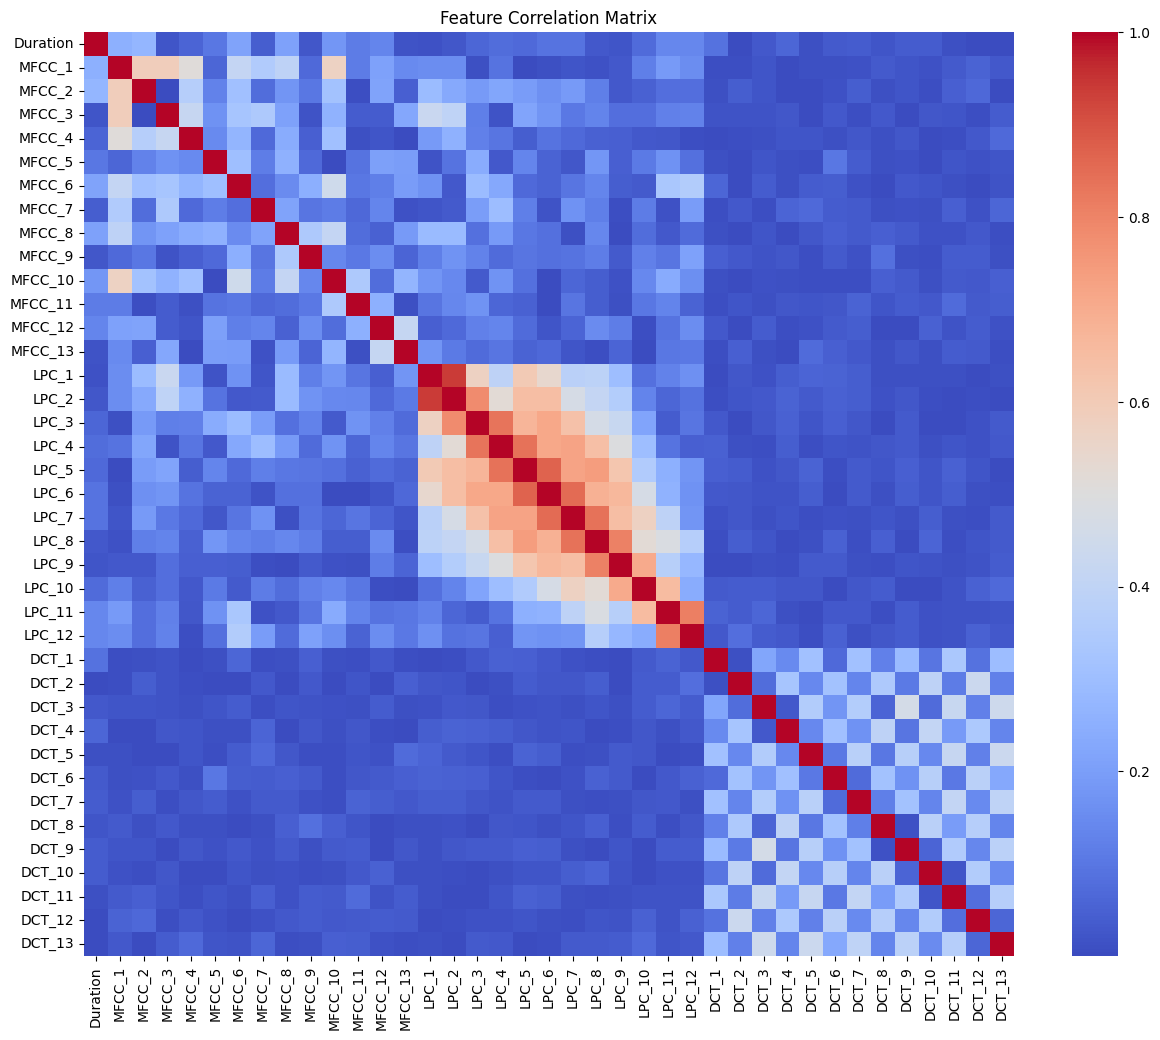

Features to drop due to high correlation (> 0.9):
['LPC_2']
Shape before reduction: (1268, 39), Shape after reduction: (1268, 38)
Test set shape before reduction: (259, 39), Test set shape after reduction: (259, 38)
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.836 |       0.841 |    0.836 |      0.836 |
| kNN          | test      |      0.722 |       0.73  |    0.722 |      0.718 |
| RandomForest | train     |      0.968 |       0.968 |    0.968 |      0.968 |
| RandomForest | test      |      0.946 |       0.946 |    0.946 |      0.946 |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 7: Compute feature correlation matrix
# Using the original X_train to compute correlation to avoid issues with oversampled data influencing feature selection
corr_matrix = pd.DataFrame(X_train).corr().abs()

# Plot correlation heatmap for top features
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# Find features with correlation > threshold (e.g., 0.9)
threshold = 0.9
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
print(f"Features to drop due to high correlation (> {threshold}):")
print(to_drop)

# Drop correlated features from balanced train and original test sets
# Convert numpy arrays back to DataFrames using original column names
X_train_bal_df = pd.DataFrame(X_train_bal, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns) # Use original X_test columns

X_train_reduced = X_train_bal_df.drop(columns=to_drop, errors='ignore').values
X_test_reduced = X_test_df.drop(columns=to_drop, errors='ignore').values # Drop from the original test set DataFrame

print(f"Shape before reduction: {X_train_bal_df.shape}, Shape after reduction: {X_train_reduced.shape}")
print(f"Test set shape before reduction: {X_test_df.shape}, Test set shape after reduction: {X_test_reduced.shape}")

# Retrain models on reduced feature set
knn_reduced = CustomKNN(k=5)
rf_reduced = CustomRandomForest(n_estimators=10, max_depth=5)

knn_reduced.fit(X_train_reduced, y_train_bal) # Use y_train_bal for fitting kNN
rf_reduced.fit(X_train_reduced, y_train_bal) # Use y_train_bal for fitting RandomForest

knn_train_pred_reduced = knn_reduced.predict(X_train_reduced)
knn_test_pred_reduced = knn_reduced.predict(X_test_reduced)

rf_train_pred_reduced = rf_reduced.predict(X_train_reduced)
rf_test_pred_reduced = rf_reduced.predict(X_test_reduced)

# Evaluate on reduced feature set
knn_train_metrics_reduced = evaluate_model_custom(knn_train_pred_reduced, y_train_bal)
knn_test_metrics_reduced = evaluate_model_custom(knn_test_pred_reduced, y_test.values)

rf_train_metrics_reduced = evaluate_model_custom(rf_train_pred_reduced, y_train_bal)
rf_test_metrics_reduced = evaluate_model_custom(rf_test_pred_reduced, y_test.values)

# Log reduced feature set results
reduced_results = {
    'kNN': {'train': knn_train_metrics_reduced, 'test': knn_test_metrics_reduced},
    'RandomForest': {'train': rf_train_metrics_reduced, 'test': rf_test_metrics_reduced}
}

print_metrics_table(reduced_results)

Step 8: Feature Reduction using PCA implemented from scratch.

In [ ]:
import numpy as np

def pca_from_scratch(X, variance_threshold=0.95):
    # Center data mean=0
    X_centered = X - np.mean(X, axis=0)

    # Compute covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort eigenvalues and eigenvectors descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Calculate explained variance ratios
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Select number of components for specified variance threshold
    num_components = np.searchsorted(cumulative_variance, variance_threshold) + 1

    print(f"Number of components chosen to retain {variance_threshold*100}% variance: {num_components}")

    # Project data onto selected PCs
    X_reduced = np.dot(X_centered, eigenvectors[:, :num_components])

    return X_reduced, eigenvectors[:, :num_components], num_components

# Apply PCA to reduced feature set from previous step
X_train_pca, pca_components, n_components = pca_from_scratch(X_train_reduced, variance_threshold=0.95)

# Project test data as well
X_test_centered = X_test_reduced - np.mean(X_train_reduced, axis=0)  # Use train mean for centering test
X_test_pca = np.dot(X_test_centered, pca_components)

# Retrain models on PCA-transformed data
knn_pca = CustomKNN(k=5)
rf_pca = CustomRandomForest(n_estimators=10, max_depth=5)

knn_pca.fit(X_train_pca, y_train_bal)
rf_pca.fit(X_train_pca, y_train_bal)

knn_train_pred_pca = knn_pca.predict(X_train_pca)
knn_test_pred_pca = knn_pca.predict(X_test_pca)

rf_train_pred_pca = rf_pca.predict(X_train_pca)
rf_test_pred_pca = rf_pca.predict(X_test_pca)

# Evaluate on PCA data
knn_train_metrics_pca = evaluate_model_custom(knn_train_pred_pca, y_train_bal)
knn_test_metrics_pca = evaluate_model_custom(knn_test_pred_pca, y_test.values)

rf_train_metrics_pca = evaluate_model_custom(rf_train_pred_pca, y_train_bal)
rf_test_metrics_pca = evaluate_model_custom(rf_test_pred_pca, y_test.values)

pca_results = {
    'kNN': {'train': knn_train_metrics_pca, 'test': knn_test_metrics_pca},
    'RandomForest': {'train': rf_train_metrics_pca, 'test': rf_test_metrics_pca}
}
print_metrics_table(baseline_results)
print_metrics_table(pca_results)


Number of components chosen to retain 95.0% variance: 5
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN          | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| RandomForest | train     |      0.966 |       0.966 |    0.966 |      0.966 |
| RandomForest | test      |      0.954 |       0.954 |    0.954 |      0.954 |
| Model        | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN          | train     |      0.821 |       0.828 |    0.821 |      0.822 |
| kNN          | test      |      0.68  |       0.686 |    0.68  |      0.675 |
| RandomForest | train     |      0.804 |       0.805 |    0.804 |      0.804 |
| RandomForest | test      |      0.737 |       0.737 |    0.737

Step 9—Model Training with Different Classifiers

Custom Decision Tree Classifier

In [ ]:
from collections import Counter
import numpy as np

class CustomDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y), depth=0)

    def _gini(self, y):
        classes = np.unique(y)
        impurity = 1.0
        for c in classes:
            p = np.sum(y == c) / len(y)
            impurity -= p**2
        return impurity

    def _best_split(self, X, y):
        best_feature, best_thresh = None, None
        best_gini = 1.0
        n_features = X.shape[1]
        for i in range(n_features):
            thresholds = np.unique(X[:, i])
            for thresh in thresholds:
                left_mask = X[:, i] <= thresh
                right_mask = X[:, i] > thresh
                if np.sum(left_mask) < self.min_samples_split or np.sum(right_mask) < self.min_samples_split:
                    continue
                gini_left = self._gini(y[left_mask])
                gini_right = self._gini(y[right_mask])
                gini_total = (np.sum(left_mask) * gini_left + np.sum(right_mask) * gini_right) / len(y)
                if gini_total < best_gini:
                    best_gini = gini_total
                    best_feature = i
                    best_thresh = thresh
        return best_feature, best_thresh

    def _build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split:
            common_label = Counter(y).most_common(1)[0][0]
            return {'type': 'leaf', 'class': common_label}

        feature, thresh = self._best_split(X, y)
        if feature is None:
            common_label = Counter(y).most_common(1)[0][0]
            return {'type': 'leaf', 'class': common_label}

        left_idx = X[:, feature] <= thresh
        right_idx = X[:, feature] > thresh
        left_branch = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_branch = self._build_tree(X[right_idx], y[right_idx], depth + 1)
        return {'type': 'node', 'feature': feature, 'threshold': thresh,
                'left': left_branch, 'right': right_branch}

    def _predict_sample(self, x, node):
        if node['type'] == 'leaf':
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self._predict_sample(x, node['left'])
        else:
            return self._predict_sample(x, node['right'])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_sample(sample, self.tree) for sample in X])


Custom Random Forest

In [ ]:
class CustomRandomForest:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=10):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        n_samples = self.X.shape[0]
        self.trees = []
        for _ in range(self.n_estimators):
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            tree = CustomDecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(self.X[idxs], self.y[idxs])
            self.trees.append(tree)

    def predict(self, X):
        X = np.array(X)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote for classification
        preds = []
        for i in range(X.shape[0]):
            vals, counts = np.unique(tree_preds[:, i], return_counts=True)
            preds.append(vals[np.argmax(counts)])
        return np.array(preds)


SVM

In [ ]:
class CustomLinearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.where(np.array(y) <= 0, -1, 1)  # binary labels to -1, 1
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    db = y[idx]
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        X = np.array(X)
        approx = np.dot(X, self.w) + self.b
        return np.where(approx >= 0, 1, 0)


Multilayer Perceptron (One Hidden Layer)

In [ ]:
class CustomMLP:
    def __init__(self, input_size, hidden_size=10, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.input_size = input_size
        self.hidden_size = hidden_size
        self._init_weights()

    def _init_weights(self):
        # Initialize weights and biases
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, 1) * 0.01
        self.b2 = 0

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _sigmoid_derivative(self, z):
        s = self._sigmoid(z)
        return s * (1 - s)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        for _ in range(self.n_iters):
            # Forward pass
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = np.tanh(Z1)
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self._sigmoid(Z2)

            # Compute loss (binary cross entropy)
            m = y.shape[0]
            loss = -np.mean(y * np.log(A2 + 1e-8) + (1 - y) * np.log(1 - A2 + 1e-8))

            # Backward pass
            dZ2 = A2 - y
            dW2 = (1/m) * np.dot(A1.T, dZ2)
            db2 = (1/m) * np.sum(dZ2)
            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * (1 - np.power(A1, 2))
            dW1 = (1/m) * np.dot(X.T, dZ1)
            db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

            # Update weights
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

    def predict(self, X):
        X = np.array(X)
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = np.tanh(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self._sigmoid(Z2)
        return (A2 >= 0.5).astype(int).flatten()


XGBoost

In [ ]:
import numpy as np
from collections import Counter

# Custom Naive Bayes (Gaussian)
class CustomNaiveBayes:
    def fit(self, X, y):
        self.X = np.array(X)
        self.y = np.array(y)
        self.classes = np.unique(self.y)
        n_features = self.X.shape[1]

        self.mean = {}
        self.var = {}
        self.priors = {}

        for cls in self.classes:
            X_c = self.X[self.y == cls]
            self.mean[cls] = X_c.mean(axis=0)
            self.var[cls] = X_c.var(axis=0)
            self.priors[cls] = X_c.shape[0] / self.X.shape[0]

    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(- ((x - mean) ** 2) / (2 * var + 1e-9))
        denominator = np.sqrt(2 * np.pi * var + 1e-9)
        return numerator / denominator

    def predict(self, X):
        X = np.array(X)
        y_pred = []
        for x in X:
            posteriors = []
            for cls in self.classes:
                prior = np.log(self.priors[cls])
                conditional = np.sum(np.log(self._pdf(cls, x)))
                posterior = prior + conditional
                posteriors.append(posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

# Simplified Custom XGBoost skeleton (single tree boosting demonstration)

class CustomXGBoostTree:
    def __init__(self, max_depth=3, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    # Use same Decision Tree approach as CustomDecisionTree for single weak learner (should be regression tree technically)
    # For simplicity, reuse CustomDecisionTree code but training on gradients

    def fit(self, X, residuals):
        # Typically fit regression tree to residuals, but simplified here
        dtree = CustomDecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
        dtree.fit(X, residuals)
        self.tree = dtree

    def predict(self, X):
        return self.tree.predict(X)

class CustomXGBoost:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, min_samples_split=10):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.initial_pred = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.initial_pred = np.mean(y)  # initial prediction is mean for regression
        pred = np.full(y.shape, self.initial_pred)
        self.trees = []

        for _ in range(self.n_estimators):
            residuals = y - pred
            tree = CustomXGBoostTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X, residuals)
            update = tree.predict(X)
            pred += self.learning_rate * update
            self.trees.append(tree)

    def predict(self, X):
        X = np.array(X)
        pred = np.full((X.shape[0],), self.initial_pred)
        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)
        # For classification threshold at 0.5 (binary)
        return (pred >= 0.5).astype(int)


In [ ]:
import numpy as np

class CustomLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        X = np.array(X)
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)


stacking classifier

In [ ]:
class CustomStackingClassifier:
    def __init__(self, base_models_params_list, meta_model_params, base_model_classes, meta_model_class):
        """
        base_models_params_list: list of dictionaries, where each dict has `params` for a base model
        base_model_classes: list of classes corresponding to each base model
        meta_model_params: dict for meta model hyperparameters
        meta_model_class: class of meta model
        """
        self.base_models_params_list = base_models_params_list
        self.meta_model_params = meta_model_params
        self.base_model_classes = base_model_classes
        self.meta_model_class = meta_model_class
        self.base_models = []
        self.meta_model = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        self.base_models = [cls(**params) for cls, params in zip(self.base_model_classes, self.base_models_params_list)]
        base_preds = []
        for model in self.base_models:
            model.fit(X, y)
            preds = model.predict(X)
            base_preds.append(preds)

        self.base_predictions_train = np.column_stack(base_preds)

        self.meta_model = self.meta_model_class(**self.meta_model_params)
        self.meta_model.fit(self.base_predictions_train, y)

    def predict(self, X):
        X = np.array(X)
        base_preds = []
        for model in self.base_models:
            preds = model.predict(X)
            base_preds.append(preds)
        stacked_preds = np.column_stack(base_preds)
        y_pred = self.meta_model.predict(stacked_preds)
        return y_pred


In [ ]:
# Assuming CustomStackingClassifier as defined previously is available here

# Instantiate base models for stacking (choose from your existing models or new instances)
base_models_for_stacking_params = [
    {'lr': 0.01, 'n_iters': 1000}, # CustomLogisticRegression params
    {'max_depth': 5}, # CustomDecisionTree params
    {'k': 5} # CustomKNN params
]

# Meta learner for stacking
meta_model_for_stacking_params = {'lr': 0.01, 'n_iters': 1000} # CustomLogisticRegression params

# Define the classes for the base models and meta model
base_model_classes = [CustomLogisticRegression, CustomDecisionTree, CustomKNN]
meta_model_class = CustomLogisticRegression


# Create stacking classifier
stacking_model = CustomStackingClassifier(
    base_models_params_list=base_models_for_stacking_params,
    meta_model_params=meta_model_for_stacking_params,
    base_model_classes=base_model_classes,
    meta_model_class=meta_model_class
)

# Initialize models including new stacking model
knn = CustomKNN(k=5)
dt = CustomDecisionTree(max_depth=5)
rf = CustomRandomForest(n_estimators=10, max_depth=5)
nb = CustomNaiveBayes()
xgb = CustomXGBoost(n_estimators=10, learning_rate=0.1, max_depth=3)
svm = CustomLinearSVM(lr=0.001, lambda_param=0.01, n_iters=1000)
mlp = CustomMLP(input_size=X_train.shape[1], hidden_size=10, lr=0.01, n_iters=1000)
logreg = CustomLogisticRegression(lr=0.01, n_iters=1000)

models = {
    'kNN': knn,
    'DecisionTree': dt,
    'RandomForest': rf,
    'NaiveBayes': nb,
    'XGBoost': xgb,
    'SVM': svm,
    'MLP': mlp,
    'LogisticRegression': logreg,
    'Stacking': stacking_model  # Added your stacking model here
}

# Train all models
for name, model in models.items():
    print(f"Training {name}...")
    # Check if the model is MLP and needs input_size
    if name == 'MLP':
      # Re-initialize MLP with correct input size if needed
      model = CustomMLP(input_size=X_train.shape[1], hidden_size=model.hidden_size, lr=model.lr, n_iters=model.n_iters)
      models[name] = model # Update the models dictionary with the new instance
    model.fit(X_train.values, y_train.values)


# Predict and evaluate
results = {}
for name, model in models.items():
    y_train_pred = model.predict(X_train.values)
    y_test_pred = model.predict(X_test.values)
    train_metrics = evaluate_model_custom(y_train_pred, y_train.values)
    test_metrics = evaluate_model_custom(y_test_pred, y_test.values)
    results[name] = {'train': train_metrics, 'test': test_metrics}

print_metrics_table(results)

Training kNN...
Training DecisionTree...
Training RandomForest...
Training NaiveBayes...
Training XGBoost...
Training SVM...
Training MLP...
Training LogisticRegression...
Training Stacking...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


| Model              | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN                | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN                | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| DecisionTree       | train     |      0.943 |       0.943 |    0.943 |      0.943 |
| DecisionTree       | test      |      0.911 |       0.911 |    0.911 |      0.911 |
| RandomForest       | train     |      0.952 |       0.953 |    0.952 |      0.951 |
| RandomForest       | test      |      0.923 |       0.926 |    0.923 |      0.922 |
| NaiveBayes         | train     |      0.881 |       0.887 |    0.881 |      0.883 |
| NaiveBayes         | test      |      0.927 |       0.929 |    0.927 |      0.927 |
| XGBoost            | train     |      0.887 |       0.887 |    0.887 |      0.886 |
| XGBoost            | test      |      0.888 |       

In [ ]:
# nOT REQUIRED

'''# Initialize models including new Logistic Regression
knn = CustomKNN(k=5)
dt = CustomDecisionTree(max_depth=5)
rf = CustomRandomForest(n_estimators=10, max_depth=5)
nb = CustomNaiveBayes()
xgb = CustomXGBoost(n_estimators=10, learning_rate=0.1, max_depth=3)
svm = CustomLinearSVM(lr=0.001, lambda_param=0.01, n_iters=1000)
mlp = CustomMLP(input_size=X_train.shape[1], hidden_size=10, lr=0.01, n_iters=1000)
logreg = CustomLogisticRegression(lr=0.01, n_iters=1000)

models = {
    'kNN': knn,
    'DecisionTree': dt,
    'RandomForest': rf,
    'NaiveBayes': nb,
    'XGBoost': xgb,
    'SVM': svm,
    'MLP': mlp,
    'LogisticRegression': logreg
}

# Train all models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

# Predict and evaluate
results = {}
for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_metrics = evaluate_model_custom(y_train_pred, y_train)
    test_metrics = evaluate_model_custom(y_test_pred, y_test)
    results[name] = {'train': train_metrics, 'test': test_metrics}

print_metrics_table(results)'''

Training kNN...
Training DecisionTree...
Training RandomForest...
Training NaiveBayes...
Training XGBoost...
Training SVM...
Training MLP...
Training LogisticRegression...
| Model              | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN                | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN                | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| DecisionTree       | train     |      0.943 |       0.943 |    0.943 |      0.943 |
| DecisionTree       | test      |      0.911 |       0.911 |    0.911 |      0.911 |
| RandomForest       | train     |      0.97  |       0.97  |    0.97  |      0.97  |
| RandomForest       | test      |      0.946 |       0.946 |    0.946 |      0.946 |
| NaiveBayes         | train     |      0.881 |       0.887 |    0.881 |      0.883 |
| NaiveBayes         | test      |      0.927 |       

Manual Grid Search for All Custom Models

In [ ]:
# Assuming CustomStackingClassifier as defined previously is available here

# Instantiate base models for stacking (choose from your existing models or new instances)
base_models_for_stacking_params = [
    {'lr': 0.01, 'n_iters': 1000}, # CustomLogisticRegression params
    {'max_depth': 5}, # CustomDecisionTree params
    {'k': 5} # CustomKNN params
]

# Meta learner for stacking
meta_model_for_stacking_params = {'lr': 0.01, 'n_iters': 1000} # CustomLogisticRegression params

# Define the classes for the base models and meta model
base_model_classes = [CustomLogisticRegression, CustomDecisionTree, CustomKNN]
meta_model_class = CustomLogisticRegression


# Create stacking classifier
stacking_model = CustomStackingClassifier(
    base_models_params_list=base_models_for_stacking_params,
    meta_model_params=meta_model_for_stacking_params,
    base_model_classes=base_model_classes,
    meta_model_class=meta_model_class
)

# Initialize models including new stacking model
knn = CustomKNN(k=5)
dt = CustomDecisionTree(max_depth=5)
rf = CustomRandomForest(n_estimators=10, max_depth=5)
nb = CustomNaiveBayes()
xgb = CustomXGBoost(n_estimators=10, learning_rate=0.1, max_depth=3)
svm = CustomLinearSVM(lr=0.001, lambda_param=0.01, n_iters=1000)
mlp = CustomMLP(input_size=X_train.shape[1], hidden_size=10, lr=0.01, n_iters=1000)
logreg = CustomLogisticRegression(lr=0.01, n_iters=1000)

models = {
    'kNN': knn,
    'DecisionTree': dt,
    'RandomForest': rf,
    'NaiveBayes': nb,
    'XGBoost': xgb,
    'SVM': svm,
    'MLP': mlp,
    'LogisticRegression': logreg,
    'Stacking': stacking_model  # Added your stacking model here
}

# Train all models
for name, model in models.items():
    print(f"Training {name}...")
    # Check if the model is MLP and needs input_size
    if name == 'MLP':
      # Re-initialize MLP with correct input size if needed
      model = CustomMLP(input_size=X_train.shape[1], hidden_size=model.hidden_size, lr=model.lr, n_iters=model.n_iters)
      models[name] = model # Update the models dictionary with the new instance
    model.fit(X_train.values, y_train.values)


# Predict and evaluate
results = {}
for name, model in models.items():
    y_train_pred = model.predict(X_train.values)
    y_test_pred = model.predict(X_test.values)
    train_metrics = evaluate_model_custom(y_train_pred, y_train.values)
    test_metrics = evaluate_model_custom(y_test_pred, y_test.values)
    results[name] = {'train': train_metrics, 'test': test_metrics}

print_metrics_table(results)

Tuning kNN...
  Best F1-score: 0.736 with params: {'k': 3}
Tuning DecisionTree...
  Best F1-score: 0.864 with params: {'max_depth': 5, 'min_samples_split': 10}
Tuning RandomForest...
  Best F1-score: 0.883 with params: {'n_estimators': 10, 'max_depth': 3, 'min_samples_split': 5}
Tuning NaiveBayes...
  Best F1-score: 0.861 with params: {}
Tuning XGBoost...
  Best F1-score: 0.859 with params: {'n_estimators': 5, 'learning_rate': 0.05, 'max_depth': 3}
Tuning SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Best F1-score: 0.766 with params: {'lr': 0.001, 'lambda_param': 0.01, 'n_iters': 1000}
Tuning MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

  Best F1-score: 0.760 with params: {'hidden_size': 5, 'lr': 0.01, 'n_iters': 500}
Tuning LogisticRegression...
  Best F1-score: 0.757 with params: {'lr': 0.01, 'n_iters': 500}
Tuning Stacking...
  Best F1-score: 0.864 with params: {'base_models_params_list': [{'lr': 0.01, 'n_iters': 1000}, {'max_depth': 5}, {'k': 5}], 'meta_model_params': {'lr': 0.05, 'n_iters': 500}}


In [ ]:
'''from sklearn.model_selection import train_test_split
import numpy as np
from itertools import product

def manual_grid_search_all_models(X, y, test_size=0.2, random_state=42):
    # Split train/validation
    X_train_grid, X_val, y_train_grid, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    tuning_results = {}

    param_grids = {
        'kNN': {'k': [3, 5, 7, 9]},
        'DecisionTree': {'max_depth': [3, 5, 7], 'min_samples_split': [5, 10]},
        'RandomForest': {'n_estimators': [5, 10], 'max_depth': [3, 5], 'min_samples_split': [5, 10]},
        'NaiveBayes': {},  # No hyperparameters for this simple NB
        'XGBoost': {'n_estimators': [5, 10], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
        'SVM': {'lr': [0.001, 0.01], 'lambda_param': [0.01, 0.1], 'n_iters': [500, 1000]},
        'MLP': {'hidden_size': [5, 10], 'lr': [0.01, 0.05], 'n_iters': [500, 1000]},
        'LogisticRegression': {'lr': [0.01, 0.05], 'n_iters': [500, 1000]}
    }

    # Helper function to evaluate any model
    def evaluate_params(model_class, params):
        if model_class == CustomMLP:
            model = model_class(input_size=X_train_grid.shape[1], **params)
        elif model_class == CustomNaiveBayes:
            model = model_class()  # no params
        else:
            model = model_class(**params)
        model.fit(X_train_grid, y_train_grid)
        preds = model.predict(X_val)
        metrics = evaluate_model_custom(preds, y_val)
        return metrics['f1_score'], params, model

    # Map model names to classes
    model_classes = {
        'kNN': CustomKNN,
        'DecisionTree': CustomDecisionTree,
        'RandomForest': CustomRandomForest,
        'NaiveBayes': CustomNaiveBayes,
        'XGBoost': CustomXGBoost,
        'SVM': CustomLinearSVM,
        'MLP': CustomMLP,
        'LogisticRegression': CustomLogisticRegression
    }

    # Perform grid search for each model
    for model_name, model_class in model_classes.items():
        print(f"Tuning {model_name}...")
        best_f1 = -1
        best_params = None
        best_model = None

        if model_name == 'NaiveBayes':
            # Naive Bayes has no hyperparameters to tune in this implementation
            f1, params, model = evaluate_params(model_class, {})
            tuning_results[model_name] = {'best_f1_score': f1, 'best_params': params, 'best_model': model}
            print(f"  Best F1-score: {f1:.3f} with params: {params}")
            continue

        param_grid = param_grids[model_name]
        param_combinations = list(product(*param_grid.values()))

        for combo in param_combinations:
            params = dict(zip(param_grid.keys(), combo))
            f1, current_params, current_model = evaluate_params(model_class, params)

            if f1 > best_f1:
                best_f1 = f1
                best_params = current_params
                best_model = current_model

        tuning_results[model_name] = {'best_f1_score': best_f1, 'best_params': best_params, 'best_model': best_model}
        print(f"  Best F1-score: {best_f1:.3f} with params: {best_params}")

    return tuning_results

# Run grid search on the original training data
tuned_results = manual_grid_search_all_models(X_train.values, y_train.values)'''

Tuning kNN...
  Best F1-score: 0.736 with params: {'k': 3}
Tuning DecisionTree...
  Best F1-score: 0.864 with params: {'max_depth': 5, 'min_samples_split': 10}
Tuning RandomForest...
  Best F1-score: 0.908 with params: {'n_estimators': 10, 'max_depth': 5, 'min_samples_split': 10}
Tuning NaiveBayes...
  Best F1-score: 0.861 with params: {}
Tuning XGBoost...
  Best F1-score: 0.859 with params: {'n_estimators': 5, 'learning_rate': 0.05, 'max_depth': 3}
Tuning SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Best F1-score: 0.766 with params: {'lr': 0.001, 'lambda_param': 0.01, 'n_iters': 1000}
Tuning MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

  Best F1-score: 0.760 with params: {'hidden_size': 5, 'lr': 0.01, 'n_iters': 500}
Tuning LogisticRegression...
  Best F1-score: 0.757 with params: {'lr': 0.01, 'n_iters': 500}


10: Metrics Computation and Evaluation implemented as reusable functions.

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    conf_matrix = confusion_matrix(y_true, y_pred)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix
    }


In [ ]:
import pandas as pd

def evaluate_models_and_log(models, X_train, y_train, X_test, y_test):
    results = []
    for model_name, model in models.items():
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_metrics = compute_metrics(y_train, y_train_pred)
        test_metrics = compute_metrics(y_test, y_test_pred)

        results.append({
            'Model': model_name,
            'Dataset': 'train',
            'Accuracy': round(train_metrics['accuracy'], 3),
            'Precision': round(train_metrics['precision'], 3),
            'Recall': round(train_metrics['recall'], 3),
            'F1-Score': round(train_metrics['f1_score'], 3),
            'Confusion Matrix': train_metrics['confusion_matrix']
        })

        results.append({
            'Model': model_name,
            'Dataset': 'test',
            'Accuracy': round(test_metrics['accuracy'], 3),
            'Precision': round(test_metrics['precision'], 3),
            'Recall': round(test_metrics['recall'], 3),
            'F1-Score': round(test_metrics['f1_score'], 3),
            'Confusion Matrix': test_metrics['confusion_matrix']
        })
    return pd.DataFrame(results)

# Example usage after models are trained:
# df_results = evaluate_models_and_log(models, X_train, y_train, X_test, y_test)
# print(df_results)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics_comparison(df_results):
    for dataset in ['train', 'test']:
        df_subset = df_results[df_results['Dataset'] == dataset]
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
        fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))
        fig.suptitle(f'Model Performance Metrics - {dataset.capitalize()} Set', fontsize=16)
        for i, metric in enumerate(metrics):
            ax = axs[i]
            sns.barplot(x='Model', y=metric, data=df_subset, ax=ax)
            ax.set_ylim(0, 1)
            ax.set_title(metric)
            for label in ax.get_xticklabels():
                label.set_rotation(45)
                label.set_ha('right')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Example:
# plot_metrics_comparison(df_results)


In [ ]:
print_metrics_table(results)
print(tuned_results)
print(df_results)

| Model              | Dataset   |   Accuracy |   Precision |   Recall |   F1-Score |
|:-------------------|:----------|-----------:|------------:|---------:|-----------:|
| kNN                | train     |      0.835 |       0.838 |    0.835 |      0.836 |
| kNN                | test      |      0.772 |       0.774 |    0.772 |      0.773 |
| DecisionTree       | train     |      0.943 |       0.943 |    0.943 |      0.943 |
| DecisionTree       | test      |      0.911 |       0.911 |    0.911 |      0.911 |
| RandomForest       | train     |      0.952 |       0.953 |    0.952 |      0.951 |
| RandomForest       | test      |      0.923 |       0.926 |    0.923 |      0.922 |
| NaiveBayes         | train     |      0.881 |       0.887 |    0.881 |      0.883 |
| NaiveBayes         | test      |      0.927 |       0.929 |    0.927 |      0.927 |
| XGBoost            | train     |      0.887 |       0.887 |    0.887 |      0.886 |
| XGBoost            | test      |      0.888 |       

In [ ]:
def plot_confusion_matrices(df_results):
    import itertools
    df_test = df_results[df_results['Dataset'] == 'test']
    models = df_test['Model'].unique()
    for model_name in models:
        cm = df_test[df_test['Model'] == model_name]['Confusion Matrix'].values[0]
        plt.figure(figsize=(5,4))
        plt.title(f'Confusion Matrix: {model_name} (Test Set)')
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.colorbar()
        classes = range(cm.shape[0])
        tick_marks = range(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

# Example:
# plot_confusion_matrices(df_results)


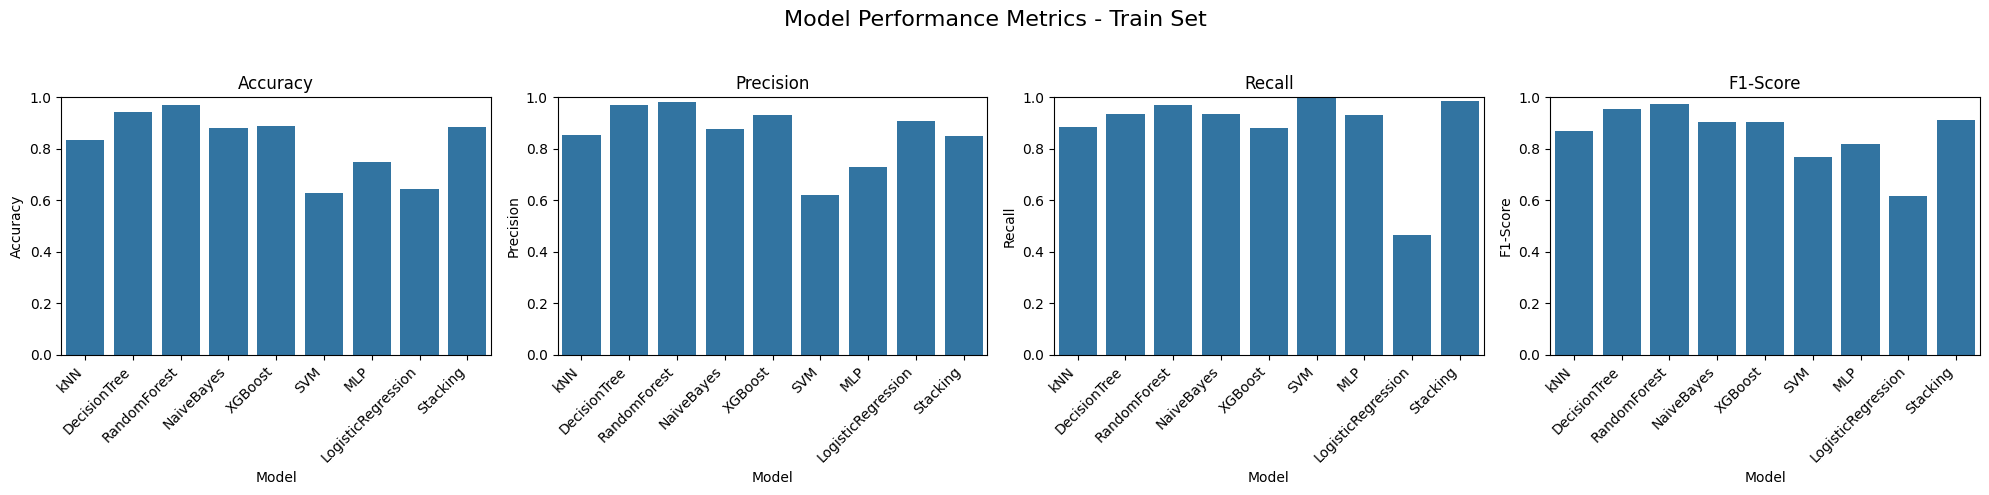

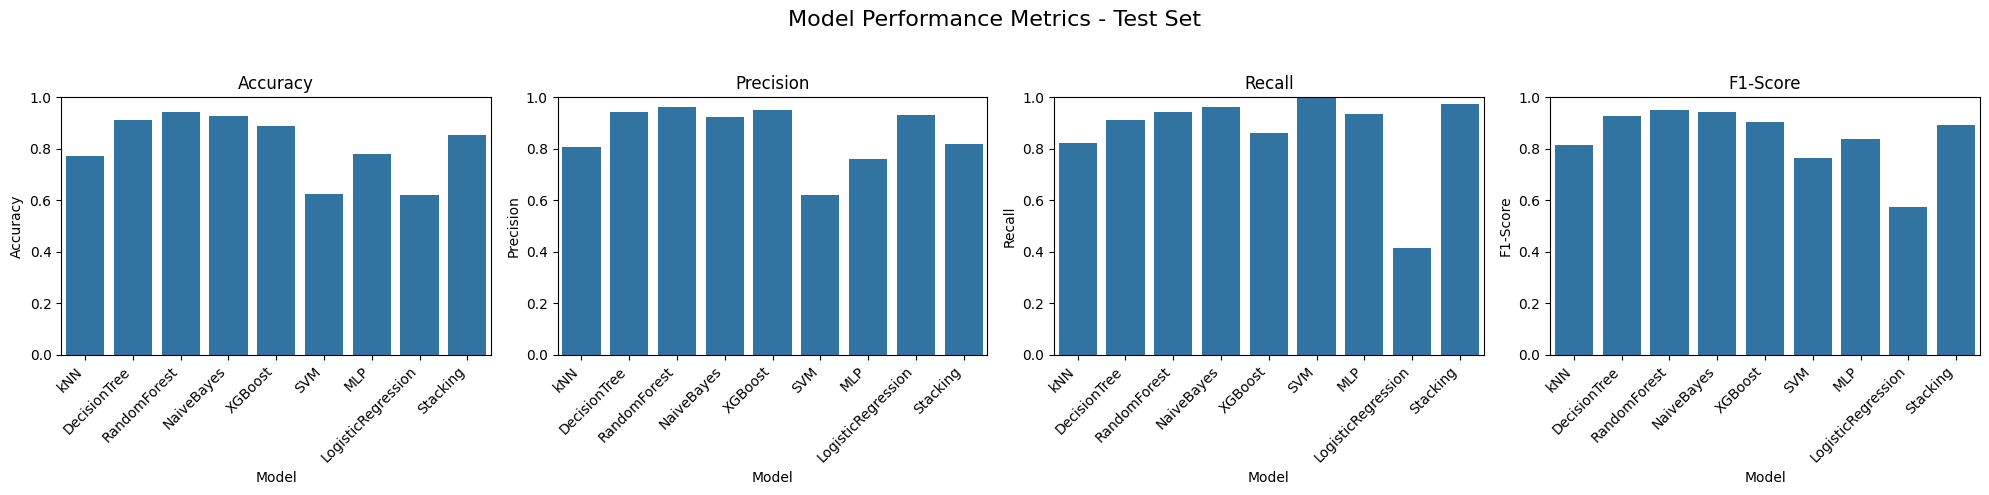

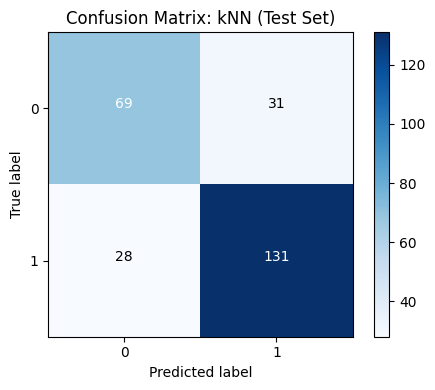

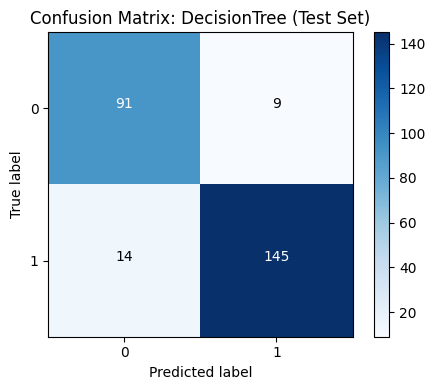

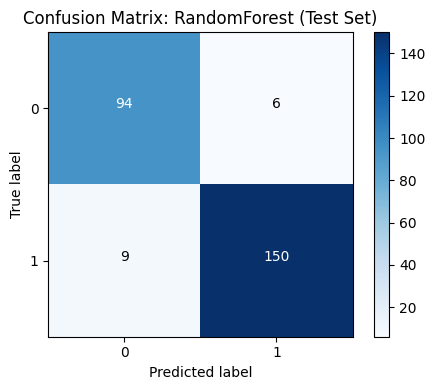

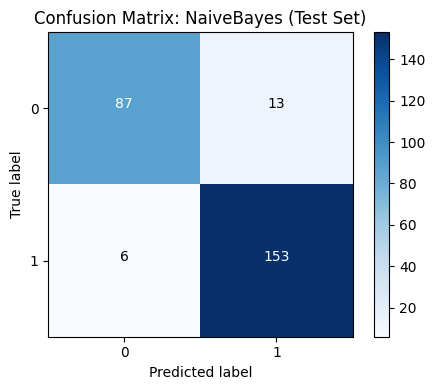

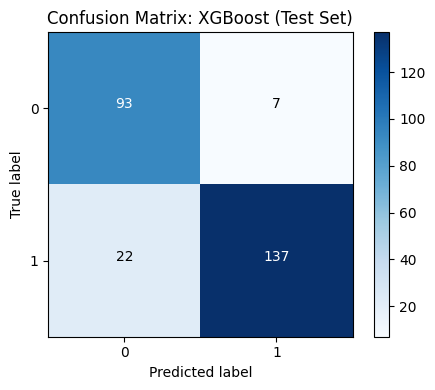

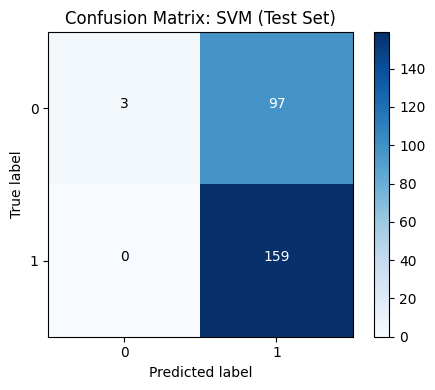

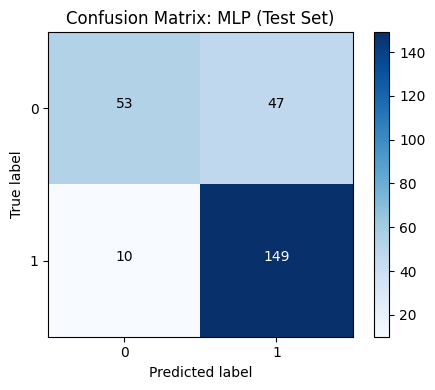

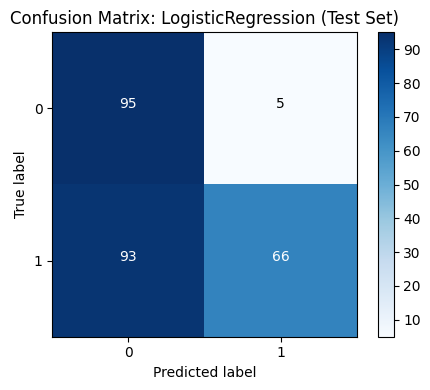

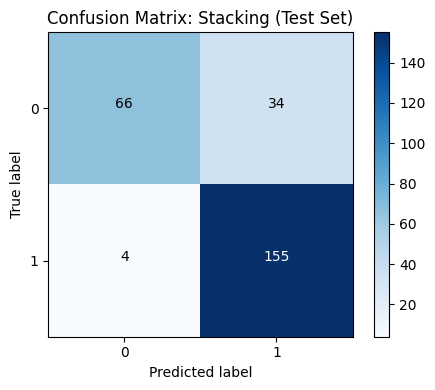

In [ ]:
# Ensure df_results contains Confusion Matrix data
df_results = evaluate_models_and_log(models, X_train, y_train, X_test, y_test)

plot_metrics_comparison(df_results)
plot_confusion_matrices(df_results)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics_comparison_combined(df_results):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    fig, axs = plt.subplots(1, len(metrics), figsize=(20, 5))
    fig.suptitle('Train vs Test Performance Comparison', fontsize=16)

    for i, metric in enumerate(metrics):
        ax = axs[i]
        sns.barplot(
            x='Model', y=metric, hue='Dataset', data=df_results,
            ax=ax, palette=['#4C72B0', '#55A868']  # Blue for train, green for test
        )
        ax.set_ylim(0, 1)
        ax.set_title(metric)
        ax.legend(title='Dataset', loc='lower right')
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


def plot_confusion_matrices_labeled(df_results):
    import itertools
    df_test = df_results[df_results['Dataset'] == 'test']
    models = df_test['Model'].unique()
    class_names = ['Non-Fluent', 'Fluent']  # Label for classes 0 and 1

    for model_name in models:
        cm = df_test[df_test['Model'] == model_name]['Confusion Matrix'].values[0]
        plt.figure(figsize=(5, 4))
        plt.title(f'Confusion Matrix: {model_name} (Test Set)')
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.colorbar()

        tick_marks = range(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45)
        plt.yticks(tick_marks, class_names)

        thresh = cm.max() / 2.0
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )

        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()


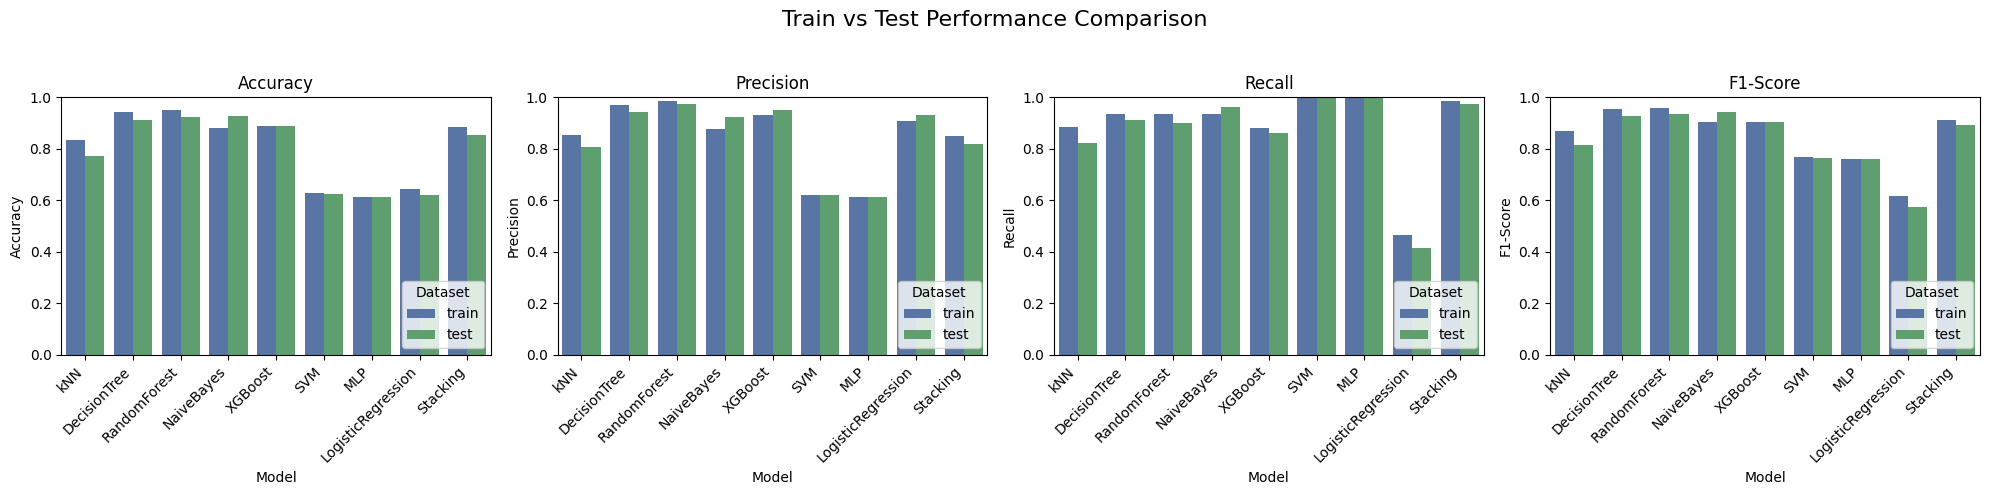

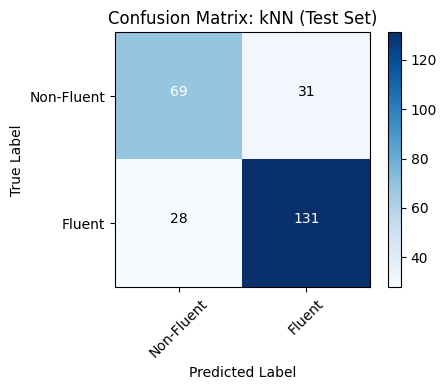

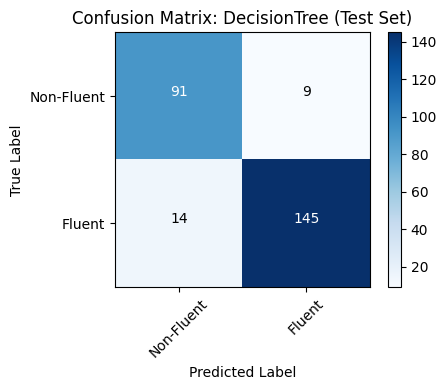

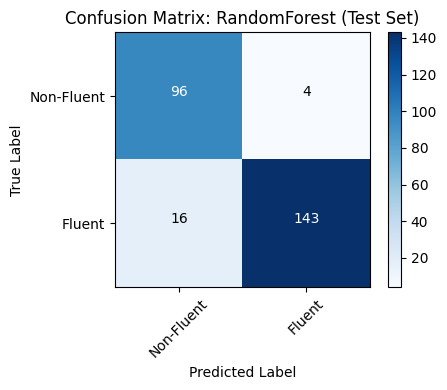

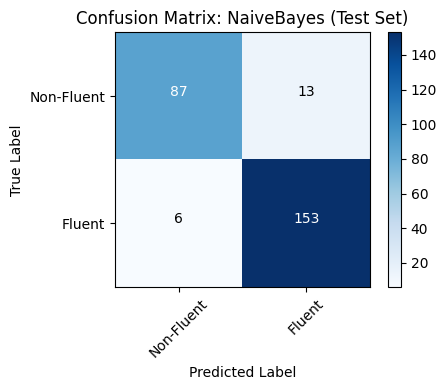

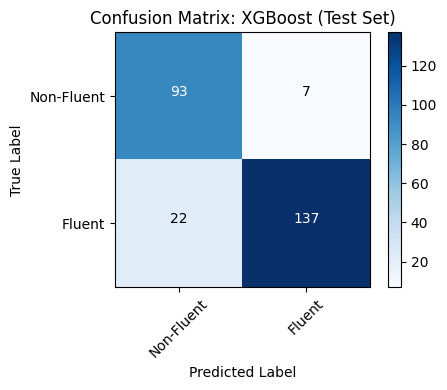

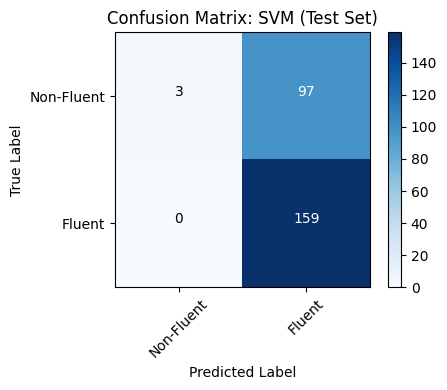

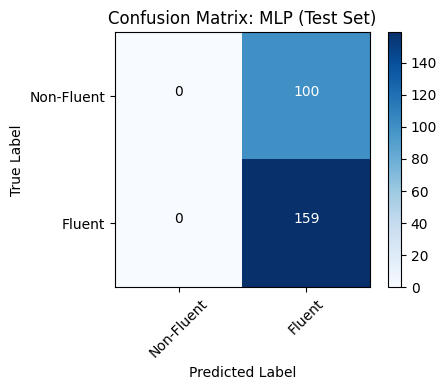

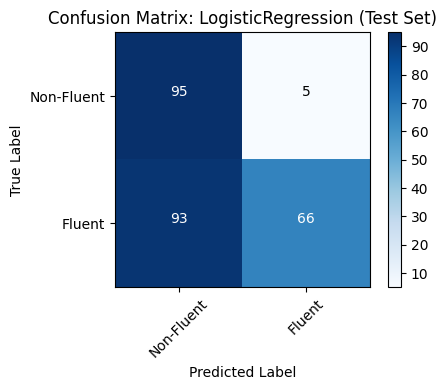

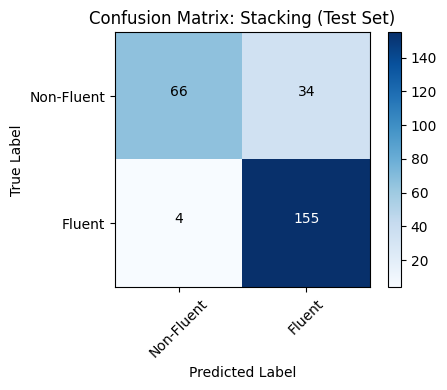

In [ ]:
df_results = evaluate_models_and_log(models, X_train, y_train, X_test, y_test)

# Plot combined metric comparison (train vs test)
plot_metrics_comparison_combined(df_results)

# Plot labeled confusion matrices
plot_confusion_matrices_labeled(df_results)

In [ ]:
# Filter for test set
df_test = df_results[df_results['Dataset'].str.lower() == 'test']

# Sort by F1-Score descending and get the best one
best_row = df_test.sort_values('F1-Score', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_f1 = best_row['F1-Score']

print(f"Best model on test data: {best_model_name} with F1-Score = {best_f1}")
print("\nFull metrics for best model:\n")
print(best_row)


Best model on test data: NaiveBayes with F1-Score = 0.942

Full metrics for best model:

Model                         NaiveBayes
Dataset                             test
Accuracy                           0.927
Precision                          0.922
Recall                             0.962
F1-Score                           0.942
Confusion Matrix    [[87, 13], [6, 153]]
Name: 7, dtype: object


check for overfit or underfit

In [ ]:
def check_overfitting_underfitting(df_results, threshold=0.1):
    # threshold: allowed train-test accuracy/F1 gap before flagging
    print("Model\t\tTrain Acc\tTest Acc\tΔAcc\tTrain F1\tTest F1\tΔF1\t\tDiagnosis")
    models = df_results['Model'].unique()
    statuses = []
    for model in models:
        row_train = df_results[(df_results['Model'] == model) & (df_results['Dataset'].str.lower() == 'train')].iloc[0]
        row_test  = df_results[(df_results['Model'] == model) & (df_results['Dataset'].str.lower() == 'test')].iloc[0]
        acc_train = row_train['Accuracy']
        acc_test  = row_test['Accuracy']
        f1_train = row_train['F1-Score']
        f1_test  = row_test['F1-Score']
        acc_gap = acc_train - acc_test
        f1_gap = f1_train - f1_test
        # Overfitting: big gap, high train, lower test
        # Underfitting: both low
        if acc_train > 0.8 and acc_gap > threshold:
            status = "Overfitting"
        elif acc_train < 0.7 and acc_test < 0.7:
            status = "Underfitting"
        else:
            status = "Good fit"
        statuses.append({
            "Model": model,
            "Train Acc": acc_train,
            "Test Acc": acc_test,
            "ΔAcc": acc_gap,
            "Train F1": f1_train,
            "Test F1": f1_test,
            "ΔF1": f1_gap,
            "Diagnosis": status
        })
        print(f"{model:16s}\t{acc_train:.3f}\t\t{acc_test:.3f}\t\t{acc_gap:.3f}\t{f1_train:.3f}\t\t{f1_test:.3f}\t{f1_gap:.3f}\t{status}")
    return pd.DataFrame(statuses)

# Usage:
# status_df = check_overfitting_underfitting(df_results)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, X_test, y_test, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_scores = []
    test_scores = []
    n_train = X.shape[0]
    for frac in train_sizes:
        size = int(n_train * frac)
        X_frac = X[:size]
        y_frac = y[:size]
        model.fit(X_frac, y_frac)
        train_pred = model.predict(X_frac)
        test_pred = model.predict(X_test)
        acc_train = accuracy_score(y_frac, train_pred)
        acc_test = accuracy_score(y_test, test_pred)
        train_scores.append(acc_train)
        test_scores.append(acc_test)
    plt.plot(train_sizes, train_scores, label="Train Accuracy")
    plt.plot(train_sizes, test_scores, label="Test Accuracy")
    plt.xlabel("Fraction of Training Data")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve: {model.__class__.__name__}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Usage example (with the model instance you want to analyze):
# plot_learning_curve(rf, X_train, y_train, X_test, y_test)


In [ ]:
# Run the analysis and print a table
status_df = check_overfitting_underfitting(df_results)
print("\n\nSummary Table:")
print(status_df)

Model		Train Acc	Test Acc	ΔAcc	Train F1	Test F1	ΔF1		Diagnosis
kNN             	0.835		0.772		0.063	0.868		0.816	0.052	Good fit
DecisionTree    	0.943		0.911		0.032	0.953		0.927	0.026	Good fit
RandomForest    	0.952		0.923		0.029	0.960		0.935	0.025	Good fit
NaiveBayes      	0.881		0.927		-0.046	0.906		0.942	-0.036	Good fit
XGBoost         	0.887		0.888		-0.001	0.905		0.904	0.001	Good fit
SVM             	0.628		0.625		0.003	0.767		0.766	0.001	Underfitting
MLP             	0.613		0.614		-0.001	0.760		0.761	-0.001	Underfitting
LogisticRegression	0.644		0.622		0.022	0.617		0.574	0.043	Underfitting
Stacking        	0.884		0.853		0.031	0.912		0.891	0.021	Good fit


Summary Table:
                Model  Train Acc  Test Acc   ΔAcc  Train F1  Test F1    ΔF1  \
0                 kNN      0.835     0.772  0.063     0.868    0.816  0.052   
1        DecisionTree      0.943     0.911  0.032     0.953    0.927  0.026   
2        RandomForest      0.952     0.923  0.029     0.960    0.935  0.025   


In [ ]:
# Run the analysis and print a table
status_df = check_overfitting_underfitting(df_results)
print("\n\nSummary Table:")
print(status_df)

Model		Train Acc	Test Acc	ΔAcc	Train F1	Test F1	ΔF1		Diagnosis
kNN             	0.835		0.772		0.063	0.868		0.816	0.052	Good fit
DecisionTree    	0.943		0.911		0.032	0.953		0.927	0.026	Good fit
RandomForest    	0.952		0.923		0.029	0.960		0.935	0.025	Good fit
NaiveBayes      	0.881		0.927		-0.046	0.906		0.942	-0.036	Good fit
XGBoost         	0.887		0.888		-0.001	0.905		0.904	0.001	Good fit
SVM             	0.628		0.625		0.003	0.767		0.766	0.001	Underfitting
MLP             	0.613		0.614		-0.001	0.760		0.761	-0.001	Underfitting
LogisticRegression	0.644		0.622		0.022	0.617		0.574	0.043	Underfitting
Stacking        	0.884		0.853		0.031	0.912		0.891	0.021	Good fit


Summary Table:
                Model  Train Acc  Test Acc   ΔAcc  Train F1  Test F1    ΔF1  \
0                 kNN      0.835     0.772  0.063     0.868    0.816  0.052   
1        DecisionTree      0.943     0.911  0.032     0.953    0.927  0.026   
2        RandomForest      0.952     0.923  0.029     0.960    0.935  0.025   


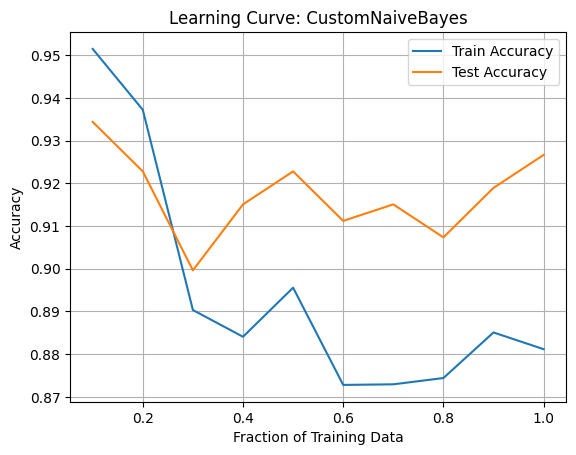

In [ ]:
# Choose a model instance you want to investigate further (e.g. Random Forest)
# If you want the best test set model:
best_test_model_name = status_df.sort_values('Test Acc', ascending=False)['Model'].iloc[0]
best_model_instance = models[best_test_model_name]  # models is your models dict

# Plot learning curve for best model
plot_learning_curve(best_model_instance, X_train, y_train, X_test, y_test)

Feature importance for Custom Random Forest

In [ ]:
def custom_random_forest_feature_importance(rf_model, n_features):
    # Count how many times each feature is used in all trees
    feature_counts = np.zeros(n_features)

    def count_features_in_tree(node):
        if node['type'] == 'leaf':
            return
        feature_counts[node['feature']] += 1
        count_features_in_tree(node['left'])
        count_features_in_tree(node['right'])

    for tree in rf_model.trees:
        count_features_in_tree(tree.tree)

    # Normalize counts
    importance = feature_counts / feature_counts.sum()
    return importance

# Usage example
n_features = X_train.shape[1]
rf_importance = custom_random_forest_feature_importance(rf, n_features)
for i, imp in enumerate(rf_importance):
    print(f"Feature {i}: Importance = {imp:.8f}")


Feature 0: Importance = 0.01530612
Feature 1: Importance = 0.15816327
Feature 2: Importance = 0.02551020
Feature 3: Importance = 0.08673469
Feature 4: Importance = 0.02040816
Feature 5: Importance = 0.03061224
Feature 6: Importance = 0.03061224
Feature 7: Importance = 0.02551020
Feature 8: Importance = 0.01530612
Feature 9: Importance = 0.00000000
Feature 10: Importance = 0.04081633
Feature 11: Importance = 0.00000000
Feature 12: Importance = 0.00000000
Feature 13: Importance = 0.04081633
Feature 14: Importance = 0.03061224
Feature 15: Importance = 0.15816327
Feature 16: Importance = 0.02040816
Feature 17: Importance = 0.02040816
Feature 18: Importance = 0.04081633
Feature 19: Importance = 0.05102041
Feature 20: Importance = 0.08163265
Feature 21: Importance = 0.04081633
Feature 22: Importance = 0.00000000
Feature 23: Importance = 0.01020408
Feature 24: Importance = 0.02551020
Feature 25: Importance = 0.00510204
Feature 26: Importance = 0.00000000
Feature 27: Importance = 0.00000000
Fe

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a76b5741c79707b3a4065fb5f70797ea7157f16df0ebbf07314fc04f9e2f20d4
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


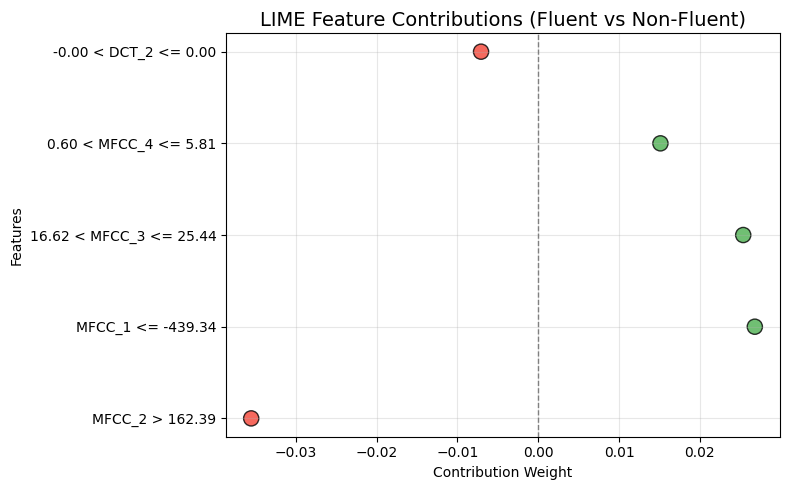

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract LIME values
lime_values = exp.as_list()
features = [f[0] for f in lime_values]
weights = np.array([f[1] for f in lime_values])

# Scatter plot for feature contributions
plt.figure(figsize=(8, 5))
colors = ['#4CAF50' if w > 0 else '#F44336' for w in weights]  # green=fluent, red=non-fluent
plt.scatter(weights, features, c=colors, s=120, alpha=0.8, edgecolors='k')

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('LIME Feature Contributions (Fluent vs Non-Fluent)', fontsize=14)
plt.xlabel('Contribution Weight')
plt.ylabel('Features')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lime_scatter_contributions.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipython-input-577766048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights, y=features, palette=['#4CAF50' if w > 0 else '#E74C3C' for w in weights])


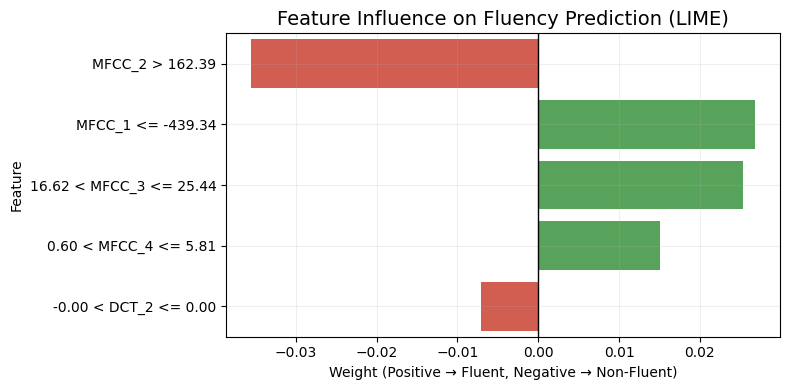

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(x=weights, y=features, palette=['#4CAF50' if w > 0 else '#E74C3C' for w in weights])
plt.axvline(0, color='black', linewidth=1)
plt.title('Feature Influence on Fluency Prediction (LIME)', fontsize=14)
plt.xlabel('Weight (Positive → Fluent, Negative → Non-Fluent)')
plt.ylabel('Feature')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('lime_bar_influence.png', dpi=300, bbox_inches='tight')
plt.show()


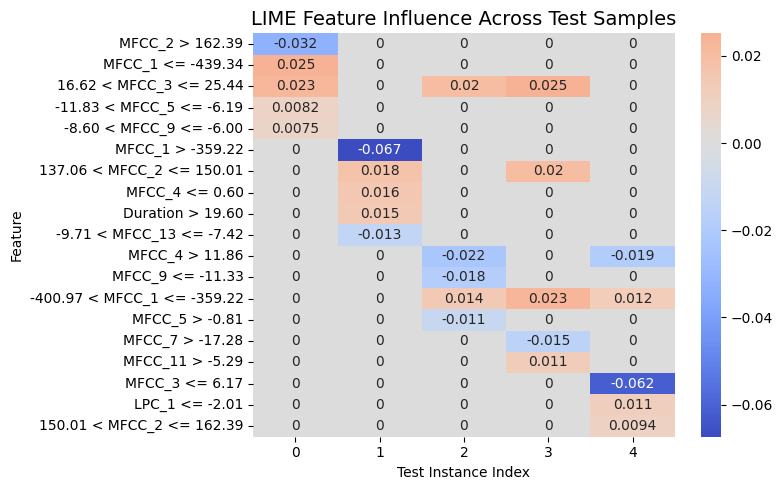

In [ ]:
import pandas as pd
import seaborn as sns

# Generate LIME explanations for multiple samples (e.g., 5)
lime_matrix = []
sample_indices = range(5)
for idx in sample_indices:
    exp_i = explainer.explain_instance(X_test_np[idx], predict_proba_fn, num_features=5)
    lime_dict = dict(exp_i.as_list())
    lime_matrix.append(lime_dict)

df_lime = pd.DataFrame(lime_matrix).fillna(0)
plt.figure(figsize=(8, 5))
sns.heatmap(df_lime.T, annot=True, cmap='coolwarm', center=0)
plt.title('LIME Feature Influence Across Test Samples', fontsize=14)
plt.xlabel('Test Instance Index')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('lime_heatmap_multi.png', dpi=300, bbox_inches='tight')
plt.show()
